# WORKSHOP- 5
# NAME: SUDHARSHINI .G
# REGISTER NO: 212225220106

In [36]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

%matplotlib inline

In [37]:
img = cv2.imread('car_plate.jpg')

In [38]:
def display(img):
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

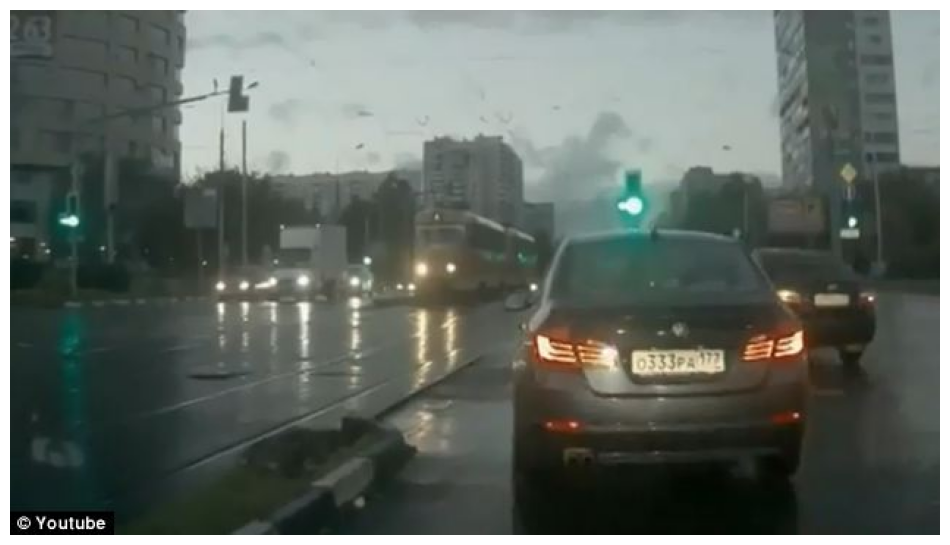

In [39]:
display(img)

In [40]:
plate_cascade = cv2.CascadeClassifier(
    'haarcascade_russian_plate_number.xml'
)


In [41]:
plate_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_russian_plate_number.xml'
)

In [42]:
def detect_plate(img):

    plate_img = img.copy()

    gray = cv2.cvtColor(plate_img, cv2.COLOR_BGR2GRAY)

    plates = plate_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5
    )

    for (x, y, w, h) in plates:

        cv2.rectangle(
            plate_img,
            (x, y),
            (x + w, y + h),
            (255, 0, 0),
            3
        )

    return plate_img

In [43]:
result = detect_plate(img)

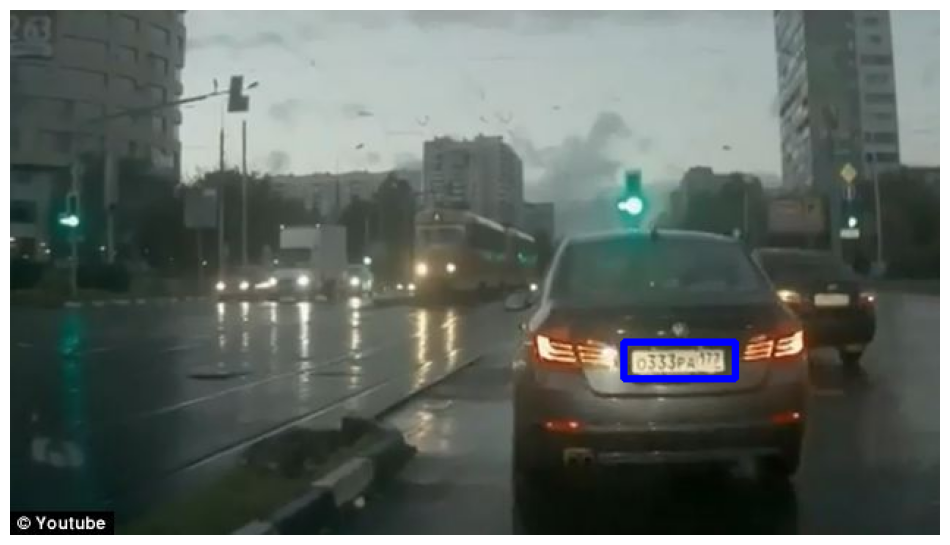

In [44]:
display(result)

In [45]:
def detect_and_blur_plate(img):

    plate_img = img.copy()

    gray = cv2.cvtColor(plate_img, cv2.COLOR_BGR2GRAY)

    plates = plate_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5
    )

    for (x, y, w, h) in plates:

        plate = plate_img[y:y+h, x:x+w]

        blurred = cv2.GaussianBlur(
            plate,
            (51, 51),
            0
        )

        plate_img[y:y+h, x:x+w] = blurred

    return plate_img

In [46]:
result = detect_and_blur_plate(img)

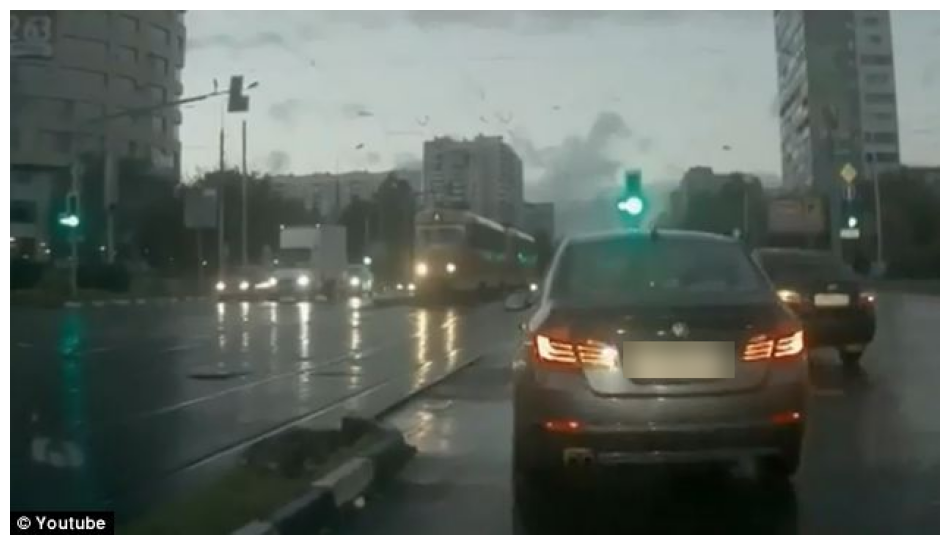

In [47]:
display(result)